In [171]:
from astropy.cosmology import LambdaCDM
from ler.image_properties import caustic_points_epl_shear
import numpy as np
from ler.lens_galaxy_population import einstein_radius

# q = 0.6
# phi = np.pi/4
# gamma = 1.8
# gamma1 = -0.05
# gamma2 = -0.05
# theta_E = 1.0
# sigma = 400.0
# zs = 2.0
# zl = 0.8
# theta_E = einstein_radius(sigma, zl, zs, cosmo=LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)).value

# Test with parameters that can cause numerical issues (high shear, steep slope, small Einstein radius)
# theta_E=2.1479577335194115e-06
# q=0.595
# phi=5.761
# e1=0.127
# e2=-0.220
# gamma=2.636
# gamma1=-0.009
# gamma2=0.171

# SIE
theta_E=1.0
q=0.9
phi=0.0
gamma=2.0
gamma1=0.0
gamma2=0.0

pts_njit = caustic_points_epl_shear(theta_E, q, phi, gamma, gamma1, gamma2, num_th=500, maginf=-1000.0)

In [172]:
# np.isfinite(pts_njit).all()
# check which one is not finite
finite_mask = np.isfinite(pts_njit)
pts_njit[~finite_mask]

array([], dtype=float64)

In [173]:
# lenstronomy
import numpy as np
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from lenstronomy.LensModel.Solver.epl_shear_solver import caustics_epl_shear
from lenstronomy.Util.param_util import phi_q2_ellipticity
from astropy.cosmology import LambdaCDM
from ler.lens_galaxy_population import einstein_radius

# q = 0.6
# phi = np.pi/4
# gamma = 1.8

# gamma1 = -0.05
# gamma2 = -0.05
# # theta_E = 1.0
# sigma = 400.0
# zs = 2.0
# zl = 0.8
# theta_E = einstein_radius(sigma, zl, zs, cosmo=LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)).value

e1, e2 = phi_q2_ellipticity(phi, q)

kwargs_lens = [
    {
        "theta_E": theta_E,
        "e1": e1,
        "e2": e2,
        "gamma": gamma,
        "center_x": 0.0,
        "center_y": 0.0,
    },
    {
        "gamma1": gamma1,
        "gamma2": gamma2,
        "ra_0": 0,
        "dec_0": 0,
    },
]

# Get the caustic curve for double-imaging region
pts_lenstronomy = caustics_epl_shear(
    kwargs_lens, return_which="double", maginf=-100.0, num_th=500, sourceplane=True
)

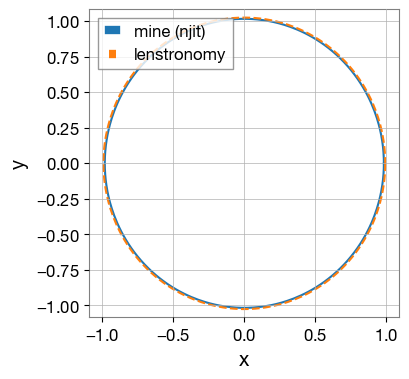

In [174]:
# plotting for visual verification
import matplotlib.pyplot as plt
plt.figure(figsize=(4, 4))
plt.plot(pts_njit[0, :], pts_njit[1, :], label='mine (njit)')
plt.plot(pts_lenstronomy[0, :], pts_lenstronomy[1, :], label='lenstronomy', linestyle='dashed')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
# EPS = 1e-1
# plt.ylim(1.0-EPS, 1.0+EPS)
# plt.xlim(0.0-EPS, 0.0+EPS)
# plt.axvline(x=0.49, color='gray', linestyle='dotted')
plt.legend(loc='upper left')
plt.show()

In [ ]:
from astropy.cosmology import LambdaCDM
from ler.image_properties import caustic_points_epl_shear, sample_source_from_double_caustic
import numpy as np
from ler.lens_galaxy_population import einstein_radius

# q = 0.6
# phi = np.pi/4
# gamma = 1.8
# gamma1 = -0.05
# gamma2 = -0.05
# # theta_E = 1.0
# sigma = 400.0
# zs = 2.0
# zl = 0.8
# theta_E = einstein_radius(sigma, zl, zs, cosmo=LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)).value

# SIE
theta_E=1.0
q=0.9
phi=0.0
gamma=2.0
gamma1=0.0
gamma2=0.0

pts_njit = caustic_points_epl_shear(theta_E, q, phi, gamma, gamma1, gamma2)
# sample source positions from the double-imaging region
size = 10000
xs, ys = np.empty(size), np.empty(size)
for i in range(size):
    xs[i], ys[i] = sample_source_from_double_caustic(theta_E, q, phi, gamma, gamma1, gamma2)

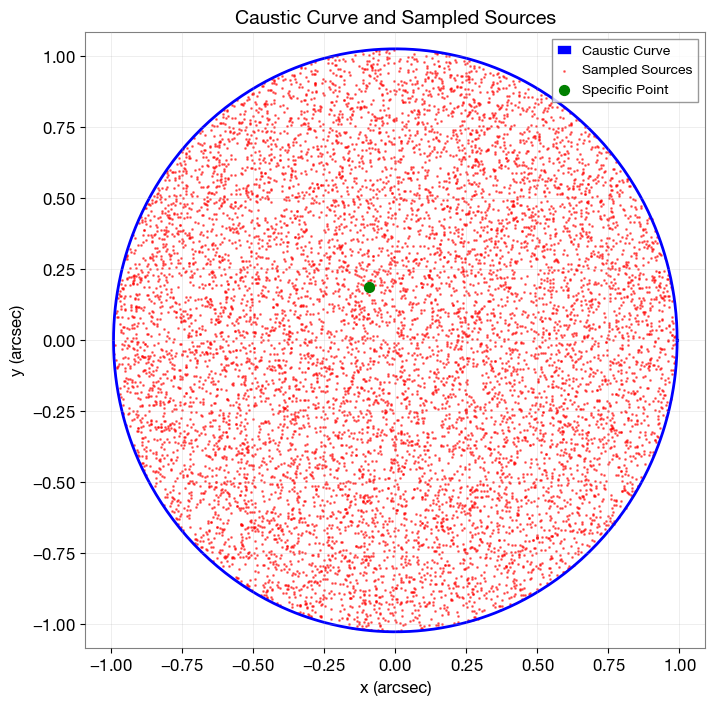

In [2]:
# plot the caustics and sampled sources
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
plt.plot(pts_njit[0, :], pts_njit[1, :],
            label='Caustic Curve', color='blue', linewidth=2)
plt.scatter(xs, ys, s=1, color='red', alpha=0.5, label='Sampled Sources')

# plot this point beta_ra = -0.09281224419273235* theta_E, beta_dec = 0.18913708325359713* theta_E
plt.scatter([-0.09281224419273235* theta_E], [0.18913708325359713* theta_E], s=50, color='green', label='Specific Point')

plt.title('Caustic Curve and Sampled Sources', fontsize=14)
plt.xlabel('x (arcsec)', fontsize=12)
plt.ylabel('y (arcsec)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

In [1]:
from astropy.cosmology import LambdaCDM
from ler.image_properties import caustic_points_epl_shear, sample_source_from_double_caustic, image_position_analytical_njit
import numpy as np
from ler.lens_galaxy_population import einstein_radius

In [2]:
q = 0.6
phi = np.pi/4
gamma = 1.8
gamma1 = -0.05
gamma2 = -0.05
theta_E = 1.0

# # SIE
# q = 1-1e-4
# phi = 0.0
# gamma = 2.0
# gamma1 = 0.
# gamma2 = 0.
# theta_E = 1.0

# theta_E=2.1479577335194115e-06
# q=0.595
# phi=5.761
# e1=0.127
# e2=-0.220
# gamma=2.636
# gamma1=-0.009
# gamma2=0.171

# Solve Image Configuration
beta_ra  = -0.25 * theta_E
beta_dec = 0.04 * theta_E
# beta_ra = -0.09281224419273235* theta_E
# beta_dec = 0.18913708325359713* theta_E
# EPS = 0.00
# beta_ra  = (0.4-EPS) * theta_E
# beta_dec = 0.0 * theta_E

x_img, y_img, tau_arr, mu_arr, itype, nimg = image_position_analytical_njit(
                x_src=beta_ra,
                y_src=beta_dec, 
                q=q,
                phi=phi, 
                gamma=gamma, 
                gamma1=gamma1, 
                gamma2=gamma2,
                theta_E=theta_E,
                magnification_limit=0.01,
            )

days_to_seconds = 24.0 * 3600.0
x_img, y_img, mu_arr, itype, tau_arr

(array([-1.13056031,  0.50945833]),
 array([0.90770181, 0.20542093]),
 array([ 2.68358644, -1.36884618]),
 array([1, 2]),
 array([-0.6951681 , -0.05578484]))

In [5]:
import numpy as np
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from lenstronomy.LensModel.Solver.epl_shear_solver import caustics_epl_shear
from lenstronomy.Util.param_util import phi_q2_ellipticity
from astropy.cosmology import LambdaCDM

# # Cosmology Setup
# sigma = 160.0  # km/s
# q = 0.9999
zs = 3.0
zl = 0.8
# cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)
# D_s = cosmo.angular_diameter_distance(zs).to('Mpc').value
# D_l = cosmo.angular_diameter_distance(zl).to('Mpc').value
# D_ls = cosmo.angular_diameter_distance_z1z2(zl, zs).to('Mpc').value
# theta_E_val = 4 * np.pi * (sigma/299792.458)**2 * D_ls / D_s  # in radians

# Lens Setup
lens_model_list = ["EPL", "SHEAR"]
lensModel = LensModel(lens_model_list=lens_model_list, z_lens=zl, z_source=zs)
lens_eq_solver = LensEquationSolver(lensModel)

e1, e2 = phi_q2_ellipticity(phi, q)

theta_E_val = theta_E
kwargs_spep = {
    'theta_E': theta_E_val,
    'e1': e1, 'e2': e2,
    'gamma': gamma,
    'center_x': 0.0, 'center_y': 0.0,
}
kwargs_shear = {'gamma1': gamma1, 'gamma2': gamma2}
kwargs_lens = [kwargs_spep, kwargs_shear]

# Solve Image Configuration
# beta_ra  = -0.25 * theta_E_val
# beta_dec = 0.04 * theta_E_val

theta_ra, theta_dec = lens_eq_solver.image_position_from_source(
    sourcePos_x=beta_ra, sourcePos_y=beta_dec, kwargs_lens=kwargs_lens,
    solver="analytical", magnification_limit=1.0/100.0, arrival_time_sort=True
)
magnifications = lensModel.magnification(theta_ra, theta_dec, kwargs_lens)

# Image Type Classification & Time Delays
hessian = lensModel.hessian(theta_ra, theta_dec, kwargs_lens)
determinant = (1 - hessian[0]) * (1 - hessian[3]) - hessian[1] * hessian[2]
trace = 2 - hessian[0] - hessian[3]

image_type = []
for j in range(len(theta_ra)):
    if determinant[j] < 0:
        image_type.append('II')
    elif trace[j] > 0:
        image_type.append('I')
    elif trace[j] < 0:
        image_type.append('III')
    else:
        image_type.append('nan')

radian_to_arcseconds = 180.0 / np.pi * 3600.0
days_to_seconds = 24.0 * 3600.0
tau = (
    lensModel.arrival_time(theta_ra, theta_dec, kwargs_lens)
    * (1.0 * radian_to_arcseconds) ** 2
    * days_to_seconds
)
try:
    delta_time_1i = (tau - tau[0]) / days_to_seconds
except:
    delta_time_1i = (tau) / days_to_seconds

# print results
# print(f"source position : {(beta_ra, beta_dec)}")
# print(f"image positions (ra, dec): {theta_ra, theta_dec))}")
# print(f"magnifications: {magnifications}")
# print(f"image types: {image_type}")
# print(f"fermat potential: {tau}")
theta_ra, theta_dec, magnifications, image_type, tau

(array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 [],
 array([], dtype=float64))

In [6]:
from astropy.cosmology import LambdaCDM
from ler.image_properties import caustic_points_epl_shear, sample_source_from_double_caustic, image_position_analytical_njit
import numpy as np
from ler.lens_galaxy_population import einstein_radius
import time

q = 0.6
phi = 0.52
gamma = 1.84
gamma1 = -0.05
gamma2 = -0.05
theta_E = 1.0
# # Cosmology Setup
zs = 3.0
zl = 0.8
sigma = 160.0  # km/s
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)
D_s = cosmo.angular_diameter_distance(zs).to('Mpc').value
D_l = cosmo.angular_diameter_distance(zl).to('Mpc').value
D_ls = cosmo.angular_diameter_distance_z1z2(zl, zs).to('Mpc').value
theta_E_val = 4 * np.pi * (sigma/299792.458)**2 * D_ls / D_s  # in radians

# ---------
# my code 
# ---------
# sample source positions from the double-imaging region
size = 10000
xs, ys = np.empty(size), np.empty(size)
for i in range(size):
    xs[i], ys[i] = sample_source_from_double_caustic(theta_E, q, phi, gamma, gamma1, gamma2)

max_img = 4  # maximum number of images for EPL+Shear is 4
beta_x_arr = np.full(size, np.nan)
beta_y_arr = np.full(size, np.nan)
x_img_arr = np.full((size, max_img), np.nan)
y_img_arr = np.full((size, max_img), np.nan)
tau_arr = np.full((size, max_img), np.nan)
mu_arr = np.full((size, max_img), np.nan)
itype = np.full((size, max_img), '', dtype='<U2')
n_img_arr = np.full(size, 0, dtype=int)

Mpc_to_m = 3.08567758 * 10**22 # with more precision 3.085677581491367e22
# time-delay distance
C_LIGHT = 299792458.0  # m/s
D_dt = (1.0 + zl) * (D_l * D_s / D_ls) * Mpc_to_m # in meters

start_time = time.time()
for i in range(size):
    x, y, arrival_time, mu, image_type, n = image_position_analytical_njit(
                x_src=xs[i],
                y_src=ys[i], 
                q=q,
                phi=phi, 
                gamma=gamma, 
                gamma1=gamma1, 
                gamma2=gamma2,
                theta_E=theta_E,
            )
            
    n = min(n, max_img)  # enforce max_img limit
    mu_arr[i, :n] = mu[:n]

    # rescale to physical units
    x_img_arr[i, :n] = x[:n] * theta_E_val
    y_img_arr[i, :n] = y[:n] * theta_E_val
    beta_x_arr[i] = beta_x_arr[i] * theta_E_val
    beta_y_arr[i] = beta_y_arr[i] * theta_E_val

    # rescale time delays
    tau_hat = arrival_time[:n]
    # Fermat potential rescales as theta_E^2
    tau_phys = tau_hat * (theta_E_val * theta_E_val)
    # physical time delays in days: Δt = (D_dt/c) * Δtau
    tau_arr[i, :n] = (D_dt / C_LIGHT) * tau_phys

    # image type
    itype[i, :n] = image_type[:n]
    # number of images
    n_img_arr[i] = n
    
end_time = time.time()
print(f"njit time: {end_time-start_time}")

njit time: 1.9588088989257812


In [7]:
import numpy as np
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from lenstronomy.LensModel.Solver.epl_shear_solver import caustics_epl_shear
from lenstronomy.Util.param_util import phi_q2_ellipticity

# lenstronomy
# Lens Setup
lens_model_list = ["EPL", "SHEAR"]
lensModel = LensModel(lens_model_list=lens_model_list, z_lens=zl, z_source=zs, cosmo=cosmo) # cosmology important
lens_eq_solver = LensEquationSolver(lensModel)

e1, e2 = phi_q2_ellipticity(phi, q)

kwargs_spep = {
    'theta_E': theta_E,
    'e1': e1, 'e2': e2,
    'gamma': gamma,
    'center_x': 0.0, 'center_y': 0.0,
}
kwargs_shear = {'gamma1': gamma1, 'gamma2': gamma2}
kwargs_lens = [kwargs_spep, kwargs_shear]

# -----
x_img_arr_ = np.full((size, max_img), np.nan)
y_img_arr_ = np.full((size, max_img), np.nan)
tau_arr_ = np.full((size, max_img), np.nan)
mu_arr_ = np.full((size, max_img), np.nan)
itype_ = np.full((size, max_img), '', dtype='<U2')
n_img_arr_ = np.full(size, 0, dtype=int)

start_time = time.time()
for i in range(size):
    theta_ra, theta_dec = lens_eq_solver.image_position_from_source(
        sourcePos_x=xs[i], sourcePos_y=ys[i], kwargs_lens=kwargs_lens,
        solver="analytical", magnification_limit=1.0/100.0, arrival_time_sort=True
    )
    n = min(len(theta_ra), max_img)  # enforce max_img limit
    x_img_arr_[i, :n] = theta_ra[:n] * theta_E_val
    y_img_arr_[i, :n] = theta_dec[:n] * theta_E_val

    magnifications = lensModel.magnification(theta_ra, theta_dec, kwargs_lens)
    mu_arr_[i, :n] = magnifications[:n]

    # Image Type Classification & Time Delays
    hessian = lensModel.hessian(theta_ra, theta_dec, kwargs_lens)
    determinant = (1 - hessian[0]) * (1 - hessian[3]) - hessian[1] * hessian[2]
    trace = 2 - hessian[0] - hessian[3]

    image_type = []
    for j in range(len(theta_ra)):
        if determinant[j] < 0:
            image_type.append('II')
        elif trace[j] > 0:
            image_type.append('I')
        elif trace[j] < 0:
            image_type.append('III')
        else:
            image_type.append('nan')
    itype_[i, :n] = image_type[:n]

    radian_to_arcseconds = 180.0 / np.pi * 3600.0
    days_to_seconds = 24.0 * 3600.0
    tau = (
        lensModel.arrival_time(theta_ra, theta_dec, kwargs_lens)
        * (theta_E_val * radian_to_arcseconds) ** 2
        * days_to_seconds
    )
    delta_time_1i = (tau - tau[0]) / days_to_seconds
    tau_arr_[i, :n] = tau[:n]    

    # number of images
    n_img_arr_[i] = n
    
end_time = time.time()
print(f"lenstronomy time: {end_time-start_time}")

# see whether image positions are the same upto 3 decimal points

lenstronomy time: 6.8806939125061035


In [8]:
# if any in n_img_arr_- n_img_arr!0, print index
idx_n_img = np.where(n_img_arr_ != n_img_arr)[0]
# check image positions for those indices
x = x_img_arr.flatten()/theta_E_val
# idx_nonan = np.where(~np.isnan(x))[0]
idx_nonan = np.arange(x.shape[0])
x_ = x_img_arr_.flatten()/theta_E_val
idx_x_img = np.where(~np.isclose(x_[idx_nonan], x[idx_nonan], rtol=1e-3, atol=0, equal_nan=True))[0]
# check y_img_arr
y = y_img_arr.flatten()/theta_E_val
y_ = y_img_arr_.flatten()/theta_E_val
idx_y_img = np.where(~np.isclose(y_[idx_nonan], y[idx_nonan], rtol=1e-3, atol=0, equal_nan=True))[0]
# check magnifications for those indices
mu = mu_arr.flatten()
mu_ = mu_arr_.flatten()
idx_mag = np.where(~np.isclose(mu[idx_nonan], mu_[idx_nonan], rtol=1e-3, atol=0, equal_nan=True))[0]
# time delays
dt = tau_arr.flatten()
dt_ = tau_arr_.flatten()
idx_dt = np.where(~np.isclose(dt[idx_nonan], dt_[idx_nonan], rtol=1e-3, atol=0, equal_nan=True))[0]

print(f"indices with different number of images: {idx_n_img}")
print(f"indices with different image positions: {idx_x_img}")
print(f"indices with different image positions: {len(idx_x_img)}")
print(f"indices with different magnifications: {len(idx_mag)}")
print(f"indices with different time delays: {len(idx_dt)}")


indices with different number of images: []
indices with different image positions: []
indices with different image positions: 0
indices with different magnifications: 0
indices with different time delays: 0


In [9]:
np.array_equal(np.where(~np.isnan(x))[0], np.where(~np.isnan(dt_))[0])

True

In [10]:
idx = int(2/4)

xs[idx], ys[idx], x_img_arr[idx], x_img_arr_[idx]

(np.float64(0.2843101020436828),
 np.float64(-0.4167342110391786),
 array([ 1.84176692e-06, -7.03295960e-07,             nan,
                    nan]),
 array([ 1.84176692e-06, -7.03295960e-07,             nan,
                    nan]))

In [11]:
x_img_arr, x_img_arr_

(array([[ 1.84176692e-06, -7.03295960e-07,             nan,
                     nan],
        [-2.10861584e-06, -4.35030799e-07, -1.50840407e-06,
          9.13099573e-07],
        [-1.54488738e-06,  3.98410401e-07, -3.13533247e-07,
          1.33680210e-06],
        ...,
        [ 2.28807314e-06, -8.04768478e-07,             nan,
                     nan],
        [-4.70396868e-07,  1.99196171e-06,  2.02884770e-06,
         -8.04682793e-07],
        [-1.74832176e-06,  5.13809942e-07,             nan,
                     nan]], shape=(10000, 4)),
 array([[ 1.84176692e-06, -7.03295960e-07,             nan,
                     nan],
        [-2.10861584e-06, -4.35030799e-07, -1.50840407e-06,
          9.13099573e-07],
        [-1.54488738e-06,  3.98410401e-07, -3.13533247e-07,
          1.33680210e-06],
        ...,
        [ 2.28807314e-06, -8.04768478e-07,             nan,
                     nan],
        [-4.70396868e-07,  1.99196171e-06,  2.02884770e-06,
         -8.04682793e-07

In [45]:
from numba import njit

@njit(fastmath=True)
def test(z, phi):

    return np.exp(-1j * phi) * z

# test
z = 1.0 + 1.0j
phi = np.pi / 4
result = test(z, phi)
print(result)

(1.414213562373095+1.1102230246251565e-16j)


In [48]:
z = 2.0 + 3.0j
q = 0.6
ang = np.angle(z)
# z in elliptical frame coordinates
zz_ell = z.real * q + 1j * z.imag
# R is the elliptical radius
# R = np.sqrt((z.real * q) ** 2 + z.imag**2)
R = np.abs(zz_ell)
r = np.abs(z)
# phi_ell is the angle in the elliptical frame
phi_ell = np.angle(zz_ell)
Roverr = np.sqrt((np.cos(ang) ** 2) * q * q + np.sin(ang) ** 2)
R, phi_ell, Roverr, R/r

(np.float64(3.2310988842807022),
 np.float64(1.1902899496825317),
 np.float64(0.8961455925668123),
 np.float64(0.8961455925668121))

In [50]:
not np.isfinite(np.nan)

True